In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.feature_selection import VarianceThreshold ,SequentialFeatureSelector as SFS
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("Loan.csv")
df=pd.DataFrame(df)
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [5]:
print(f"Shape: {df.shape}")

Shape: (20000, 36)


In [7]:
X = df.drop(["LoanApproved","ApplicationDate"], axis=1)
y = df["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (16000, 34)
Test shape: (4000, 34)


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [11]:
X_train.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.0000,16000.00000,16000.000000,16000.000000,16000.000000,...,1.600000e+04,16000.000000,16000.000000,16000.000000,1.600000e+04,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,39.730938,59325.075563,571.594625,17.510500,24902.192062,54.0330,1.51425,455.502000,0.286256,3.022063,...,3.628249e+04,4903.171698,0.799504,5.011063,7.265478e+04,0.239132,0.239275,912.944686,0.401772,50.744537
std,11.654110,40332.333800,51.029116,11.338223,13420.296053,24.6066,1.38827,241.253884,0.160072,1.739077,...,4.812399e+04,3287.866174,0.120709,2.249613,1.170384e+05,0.035446,0.042212,673.717359,0.339061,7.774913
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.0000,0.00000,60.000000,0.002672,0.000000,...,3.720000e+02,1250.000000,0.259203,0.000000,1.004000e+03,0.130101,0.113310,97.030193,0.016043,28.800000
25%,31.000000,31926.750000,540.000000,9.000000,15652.000000,36.0000,0.00000,287.000000,0.160303,2.000000,...,1.122475e+04,2645.562500,0.726801,3.000000,8.758250e+03,0.214085,0.209282,495.947179,0.179524,46.000000
50%,40.000000,48754.500000,578.000000,17.000000,21918.000000,48.0000,1.00000,403.000000,0.266116,3.000000,...,2.217450e+04,4044.208333,0.820691,5.000000,3.301250e+04,0.236221,0.235655,730.913134,0.301743,52.000000
75%,48.000000,74543.250000,609.000000,25.000000,30837.250000,72.0000,2.00000,565.000000,0.390937,4.000000,...,4.311775e+04,6173.979167,0.892231,6.000000,8.957225e+04,0.261533,0.265540,1113.462991,0.508958,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.0000,5.00000,2919.000000,0.917380,13.000000,...,1.417302e+06,25000.000000,0.998966,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,79.000000


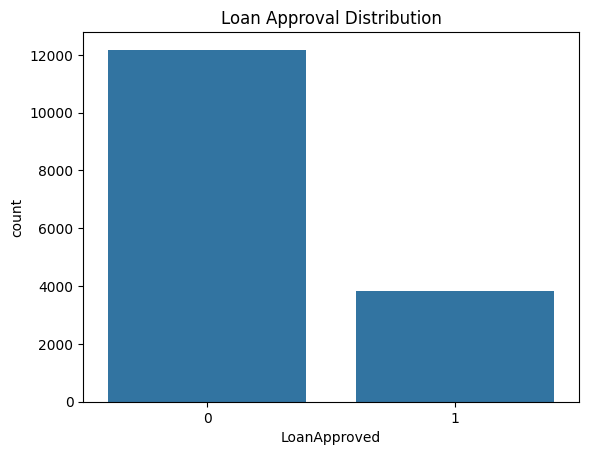

In [13]:
sns.countplot(x=y_train)
plt.title("Loan Approval Distribution")
plt.show()

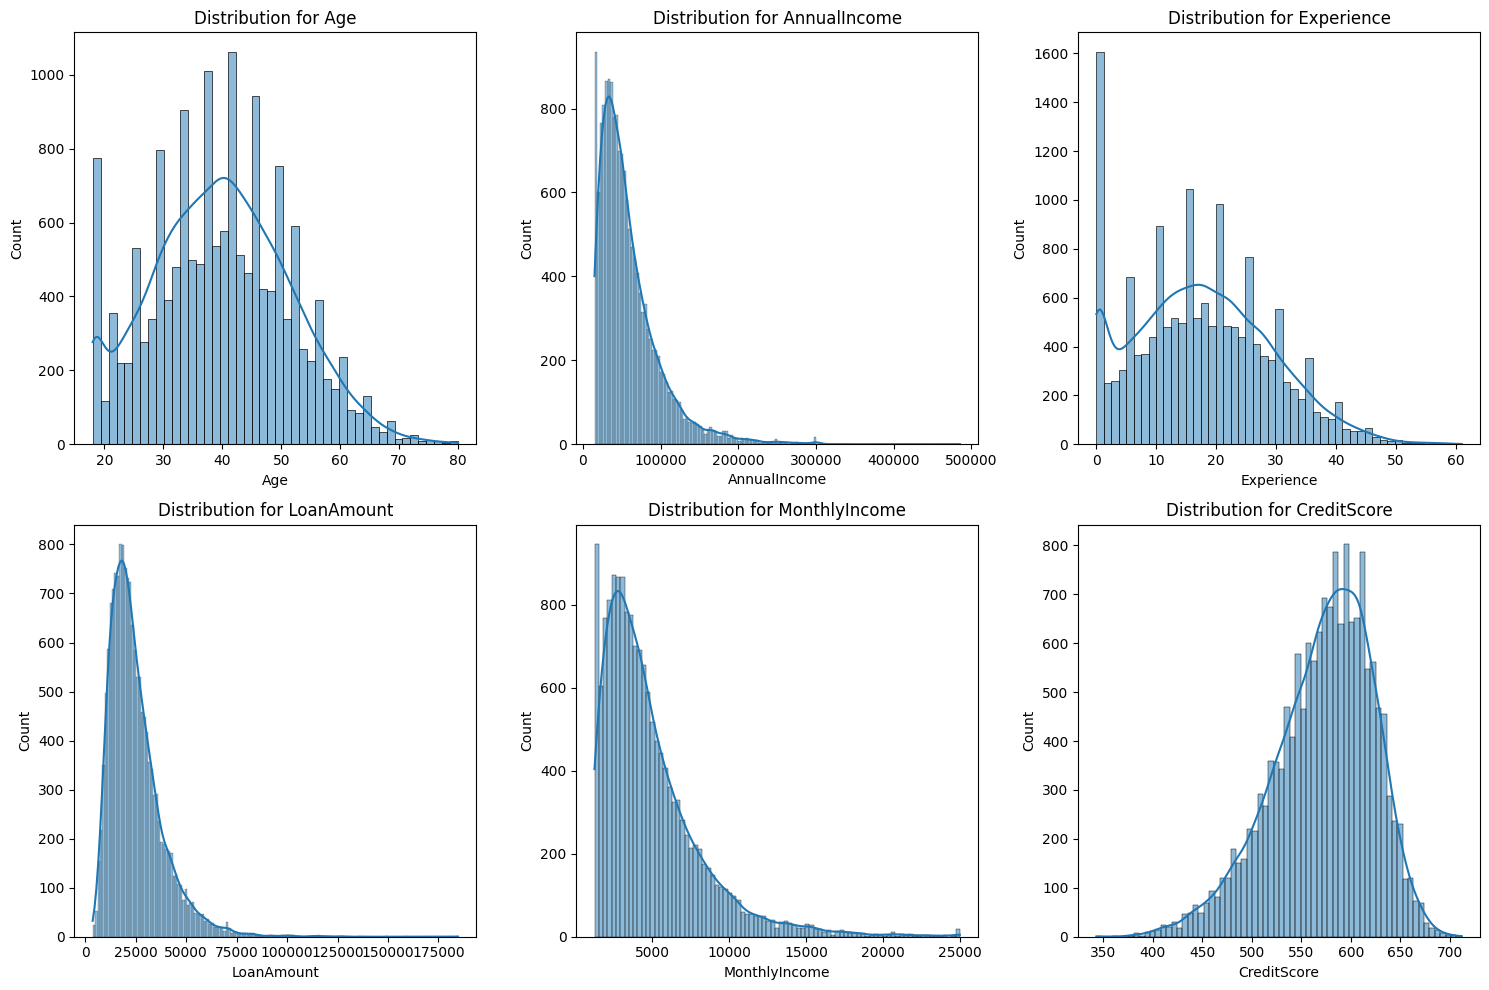

In [15]:
X_train.columns=X_train.columns.str.strip()

cols = ["Age","AnnualIncome","Experience","LoanAmount","MonthlyIncome","CreditScore"]

fig, ax = plt.subplots(2, 3,figsize=(15,10))

ax = ax.flatten()

for i, col in enumerate(cols):
  sns.histplot(X_train[col], kde=True, ax=ax[i])
  ax[i].set_title(f"Distribution for {col}")
  ax[i].set_xlabel(f"{col}")
  ax[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

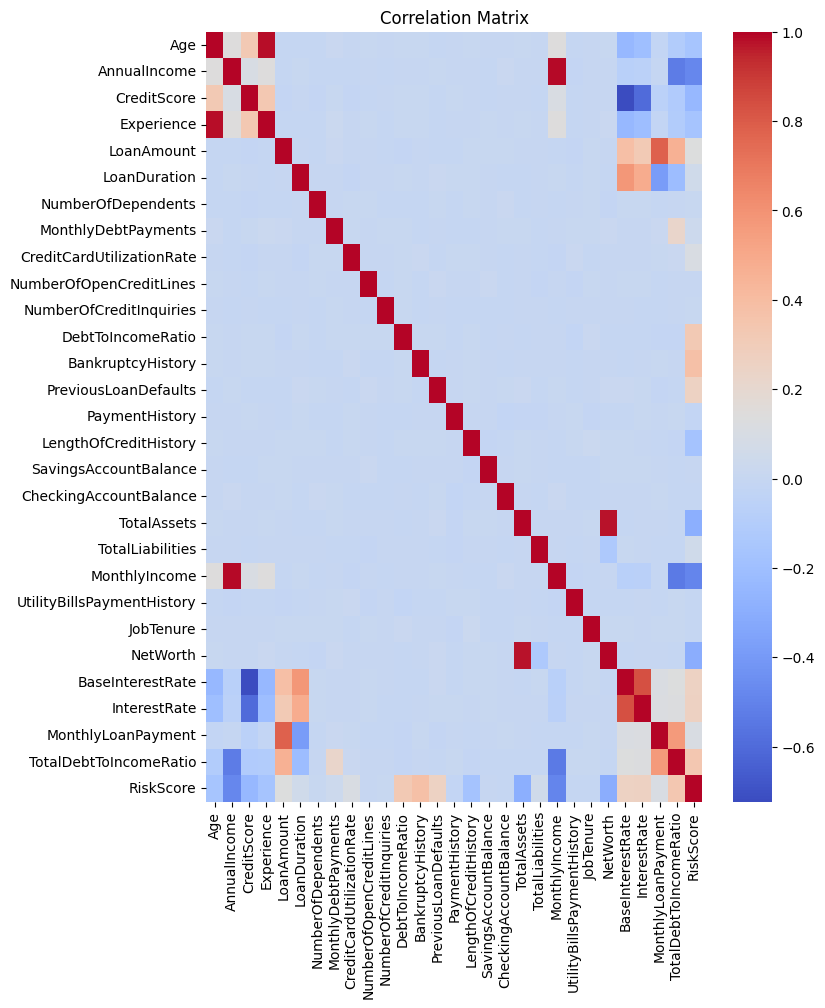

In [16]:
plt.figure(figsize=(8,10))
sns.heatmap(X_train.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

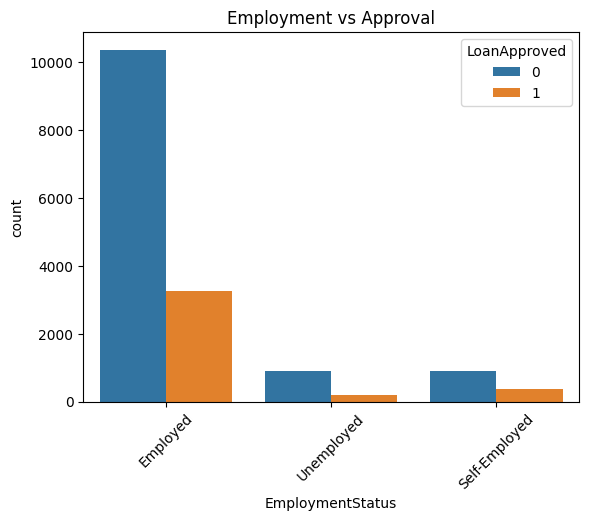

In [17]:
sns.countplot(x=X_train['EmploymentStatus'], hue=y_train)
plt.xticks(rotation=45)
plt.title("Employment vs Approval")
plt.show()

In [18]:
print(X_train.isnull().sum())

Age                           0
AnnualIncome                  0
CreditScore                   0
EmploymentStatus              0
EducationLevel                0
Experience                    0
LoanAmount                    0
LoanDuration                  0
MaritalStatus                 0
NumberOfDependents            0
HomeOwnershipStatus           0
MonthlyDebtPayments           0
CreditCardUtilizationRate     0
NumberOfOpenCreditLines       0
NumberOfCreditInquiries       0
DebtToIncomeRatio             0
BankruptcyHistory             0
LoanPurpose                   0
PreviousLoanDefaults          0
PaymentHistory                0
LengthOfCreditHistory         0
SavingsAccountBalance         0
CheckingAccountBalance        0
TotalAssets                   0
TotalLiabilities              0
MonthlyIncome                 0
UtilityBillsPaymentHistory    0
JobTenure                     0
NetWorth                      0
BaseInterestRate              0
InterestRate                  0
MonthlyL

In [20]:
col=["AnnualIncome","MonthlyIncome","LoanAmount"]
for c in col:
  Q1 = X_train[c].quantile(0.25)
  Q3 = X_train[c].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  X_train = X_train[(X_train[c]>lower) & (X_train[c]<upper)]
  y_train = y_train[X_train.index]

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

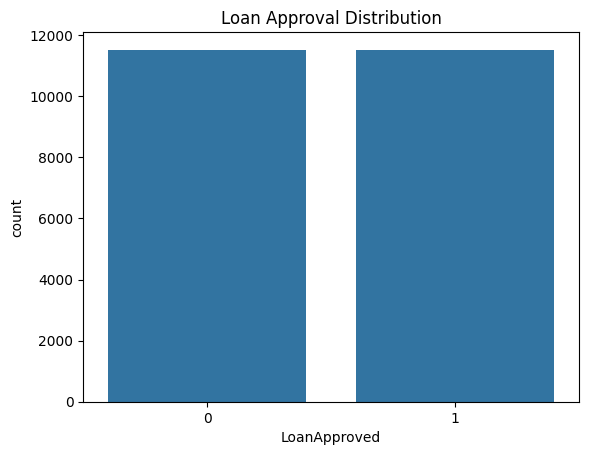

In [25]:
object_cols = X_train.select_dtypes(include='object').columns
LE=LabelEncoder()
for col in object_cols:
  X_train[col]=LE.fit_transform(X_train[col])
  X_test[col]=LE.transform(X_test[col])

bool_cols = X_train.select_dtypes(include='bool').columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)
X_train.head()

# Standardize features by removing the mean and scaling to unit variance,This is crucial for SVM performance because it ensures that all features ,
# contribute equally to the model, preventing features with larger numeric ranges  from dominating the distance calculations.                                             
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index) # transform it from array to DataFrame to use it later..
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
#over sampling
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

sns.countplot(x=y_train_res)
plt.title("Loan Approval Distribution")
plt.show()

#Dimensionality Reduction

In [28]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import VarianceThreshold

In [30]:
var = VarianceThreshold(threshold=0.9) # "0.9 because thestandardization.Since StandardScaler shifts the variance of most features toward 1.0,
                                      # a lower threshold like 0.1 wouldn't be effective in removing any redundant features."
# before transformation
features_before = X_train_res.columns

X_train_var_array = var.fit_transform(X_train_res)
X_test_var_array = var.transform(X_test_scaled) 

mask = var.get_support()
features_after = features_before[mask]

X_train_res_final = pd.DataFrame(X_train_var_array, columns=features_after) # make it DataFram again instead of Array..
X_test_final = pd.DataFrame(X_test_var_array, columns=features_after)

print(f"Befor var_threshold: {len(features_before)}")
print(f"after var_threshold: {X_train_res_final.shape[1]}")

Befor var_threshold: 34
after var_threshold: 19


In [32]:
pca = PCA(n_components=0.95)
X_train_res_pca = pca.fit_transform(X_train_res_final)
X_test_pca = pca.transform(X_test_final)

print(f"Number of components chosen: {X_train_res_pca.shape[1]}")

Number of components chosen: 14


In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC


# Define the hyperparameter space for the SVM model. 
# We test different values for C and Gamma to find the optimal balance 
# between model complexity and generalization.
param_grid = {
    'C': [0.1, 1, 10, 100],           
    'gamma': ['scale', 'auto'],      
    'kernel': ['rbf']          
}

# Initialize GridSearchCV with 5-fold Cross-Validation.
# 'refit=True' ensures that the model is automatically retrained on the whole 
# training set using the best found parameters.
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=5)

grid.fit(X_train_res_pca, y_train_res)

print("best parameters:", grid.best_params_)

grid_predictions = grid.predict(X_test_pca)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   7.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   7.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   7.2s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   6.8s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   6.7s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   6.7s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   6.8s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   7.6s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   8.0s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   7.8s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   5.0s
[CV] END .......................C=1, gamma=scale,

In [38]:
print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3044
           1       0.79      0.77      0.78       956

    accuracy                           0.90      4000
   macro avg       0.86      0.85      0.85      4000
weighted avg       0.89      0.90      0.89      4000



In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC


# Define the hyperparameter space for the SVM model. 
# We test different values for C and Gamma to find the optimal balance 
# between model complexity and generalization.
param_grid = {
    'C': [0.1, 1, 10, 100],           
    'gamma': ['scale', 'auto'],      
    'kernel': ['rbf']          
}

# Initialize GridSearchCV with 3-fold or Cross-Validation.
# 'refit=True' ensures that the model is automatically retrained on the whole 
# training set using the best found parameters.
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2, cv=3)

grid.fit(X_train_res_pca, y_train_res)

print("best parameters:", grid.best_params_)

grid_predictions = grid.predict(X_test_pca)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   5.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   6.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   6.2s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   5.8s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   6.7s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=   6.5s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   4.7s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   4.6s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   4.7s
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time=   4.3s
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time=   4.8s
[CV] END ........................C=1, gamma=auto,

In [42]:
print(classification_report(y_test, grid_predictions))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      3044
           1       0.79      0.83      0.81       956

    accuracy                           0.91      4000
   macro avg       0.87      0.88      0.87      4000
weighted avg       0.91      0.91      0.91      4000



Model Evaluation Insight:
The configuration with CV=5 and C=100 achieved a robust 90% accuracy.
Although CV=3 showed a slightly higher 91%, CV=5 is more reliable as
it validates the model across more subsets of the data, reducing
the likelihood of results being due to a lucky split